In [1]:
"""
Comprehensive Testing Script for XCiT Multitask Model
Loads model weights and evaluates on test data from H5 file
Generates confusion matrix, regression plots, ROC-AUC curve, and metrics
"""

import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps")
print(f"Device: {DEVICE}")

Device: mps


In [2]:
## 1 · Hyperparameters & Configuration

In [3]:
# ── Configuration ──────────────────────────────────────────────────────────
H5_PATH     = "Dataset_Specific_labelled_full_only_for_2i.h5"
MODEL_PATH  = "models/linear-vit/best_xcit_mt_sc.pth"
BATCH_SIZE  = 64
NUM_WORKERS = 0

# ── Normalization stats (loaded from training data) ──────────────────────────
NORM_STATS_PATH = "./data-concat/norm_stats.npy"

# ── Image/Architecture ──────────────────────────────────────────────────────
IMAGE_SIZE   = 125
PATCH_SIZE   = 5
IN_CHANNELS  = 8
NUM_CLASSES  = 2
DIM          = 192
DEPTH        = 8
NUM_HEADS    = 8
MLP_RATIO    = 4
CLS_DEPTH    = 2
DROPOUT      = 0.2
DROP_PATH    = 0.05

print(f"Config: image_size={IMAGE_SIZE}, patch_size={PATCH_SIZE}, in_channels={IN_CHANNELS}")
print(f"Model: dim={DIM}, depth={DEPTH}, heads={NUM_HEADS}")
print(f"Model weights path: {MODEL_PATH}")

Config: image_size=125, patch_size=5, in_channels=8
Model: dim=192, depth=8, heads=8
Model weights path: models/linear-vit/best_xcit_mt_sc.pth


In [4]:
# Model architecture classes - required for torch.load to unpickle the saved model
class DropPath(nn.Module):
    def __init__(self, p=0.0):
        super().__init__()
        self.p = p
    def forward(self, x):
        if not self.training or self.p == 0.0: return x
        keep = 1 - self.p
        mask = (torch.rand((x.shape[0],)+(1,)*(x.ndim-1), device=x.device)<keep).float()
        return x * mask / keep

class XCA(nn.Module):
    def __init__(self, dim, num_heads=8, qkv_bias=False, dropout=0.0):
        super().__init__()
        self.num_heads, self.head_dim = num_heads, dim // num_heads
        self.temperature = nn.Parameter(torch.ones(num_heads, 1, 1))
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.proj = nn.Sequential(nn.Linear(dim, dim), nn.Dropout(dropout))
    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B,N,3,self.num_heads,C//self.num_heads).permute(2,0,3,1,4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        q = F.normalize(q.transpose(-2,-1), dim=-1, p=2)
        k = F.normalize(k.transpose(-2,-1), dim=-1, p=2)
        v = v.transpose(-2,-1)
        attn = (k @ q.transpose(-2,-1)) * self.temperature
        out = (attn.softmax(dim=-1) @ v).permute(0,3,1,2).reshape(B,N,C)
        return self.proj(out)

class LPI(nn.Module):
    def __init__(self, dim, kernel_size=3):
        super().__init__()
        pad = kernel_size // 2
        self.net = nn.Sequential(
            nn.Conv2d(dim, dim, kernel_size, padding=pad, groups=dim, bias=False),
            nn.GELU(), nn.BatchNorm2d(dim),
            nn.Conv2d(dim, dim, kernel_size, padding=pad, groups=dim, bias=False))
    def forward(self, x, H, W):
        B, N, C = x.shape
        return self.net(x.transpose(1,2).view(B,C,H,W)).flatten(2).transpose(1,2)

class XCiTBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4, dropout=0.0, drop_path=0.0):
        super().__init__()
        self.norm1, self.norm2, self.norm3 = nn.LayerNorm(dim), nn.LayerNorm(dim), nn.LayerNorm(dim)
        self.xca, self.lpi = XCA(dim, num_heads=num_heads, dropout=dropout), LPI(dim)
        self.ffn = nn.Sequential(nn.Linear(dim,dim*mlp_ratio), nn.GELU(), nn.Dropout(dropout),
                                 nn.Linear(dim*mlp_ratio,dim), nn.Dropout(dropout))
        self.drop_path = DropPath(drop_path) if drop_path > 0 else nn.Identity()
    def forward(self, x, H, W):
        x = x + self.drop_path(self.xca(self.norm1(x)))
        x = x + self.drop_path(self.lpi(self.norm2(x), H, W))
        x = x + self.drop_path(self.ffn(self.norm3(x)))
        return x

class ClassAttention(nn.Module):
    def __init__(self, dim, num_heads=8):
        super().__init__()
        self.num_heads, self.scale = num_heads, (dim // num_heads) ** -0.5
        self.q, self.kv, self.proj = nn.Linear(dim, dim), nn.Linear(dim, dim*2), nn.Linear(dim, dim)
    def forward(self, x):
        B, N, C = x.shape
        q = self.q(x[:,:1]).reshape(B,1,self.num_heads,C//self.num_heads).permute(0,2,1,3)
        kv = self.kv(x).reshape(B,N,2,self.num_heads,C//self.num_heads).permute(2,0,3,1,4)
        k, v = kv[0], kv[1]
        attn = (q @ k.transpose(-2,-1)) * self.scale
        out = (attn.softmax(dim=-1) @ v).transpose(1,2).reshape(B,1,C)
        return torch.cat([self.proj(out), x[:,1:]], dim=1)

class ClassAttentionBlock(nn.Module):
    def __init__(self, dim, num_heads):
        super().__init__()
        self.norm1, self.norm2 = nn.LayerNorm(dim), nn.LayerNorm(dim)
        self.attn = ClassAttention(dim, num_heads)
        self.ffn = nn.Sequential(nn.Linear(dim, dim*4), nn.GELU(), nn.Linear(dim*4, dim))
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        return torch.cat([x[:,:1] + self.ffn(self.norm2(x[:,:1])), x[:,1:]], dim=1)

class SinCos2DPosEmb(nn.Module):
    def __init__(self, dim, temperature=10000):
        super().__init__()
        self.temperature, self.proj = temperature, nn.Linear(64, dim)
    def forward(self, H, W, device):
        y_pos = torch.arange(H, device=device).unsqueeze(1).float()
        x_pos = torch.arange(W, device=device).unsqueeze(1).float()
        omega = 1.0 / (self.temperature ** (torch.arange(16, device=device).float() / 16))
        y_enc = torch.cat([torch.sin(y_pos*omega), torch.cos(y_pos*omega)], dim=-1)
        x_enc = torch.cat([torch.sin(x_pos*omega), torch.cos(x_pos*omega)], dim=-1)
        pos = torch.cat([y_enc.unsqueeze(1).expand(H,W,32), x_enc.unsqueeze(0).expand(H,W,32)], dim=-1).reshape(H*W,64)
        return self.proj(pos)

class XCiTMultitask(nn.Module):
    def __init__(self, image_size=IMAGE_SIZE, patch_size=PATCH_SIZE, in_channels=IN_CHANNELS, 
                 num_classes=NUM_CLASSES, dim=DIM, depth=DEPTH, num_heads=NUM_HEADS,
                 mlp_ratio=MLP_RATIO, cls_depth=CLS_DEPTH, dropout=DROPOUT, drop_path=DROP_PATH):
        super().__init__()
        self.patch_size, self.H, self.W = patch_size, image_size // patch_size, image_size // patch_size
        self.patch_embed = nn.Conv2d(in_channels, dim, kernel_size=patch_size, stride=patch_size)
        self.emb_norm, self.pos_emb = nn.LayerNorm(dim), SinCos2DPosEmb(dim)
        dpr = [x.item() for x in torch.linspace(0, drop_path, depth)]
        self.blocks = nn.ModuleList([XCiTBlock(dim, num_heads, mlp_ratio, dropout, dpr[i]) for i in range(depth)])
        self.norm = nn.LayerNorm(dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.cls_blocks = nn.ModuleList([ClassAttentionBlock(dim, num_heads) for _ in range(cls_depth)])
        self.cls_norm = nn.LayerNorm(dim)
        self.head_cls = nn.Linear(dim, num_classes)
        self.head_mass = nn.Sequential(nn.Linear(dim, dim//2), nn.GELU(), nn.Dropout(0.1), nn.Linear(dim//2, 1))
        self.head_pt = nn.Sequential(nn.Linear(dim, dim//2), nn.GELU(), nn.Dropout(0.1), nn.Linear(dim//2, 1))
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, (nn.LayerNorm, nn.BatchNorm2d)):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
    
    def forward(self, x):
        B, ps = x.shape[0], self.patch_size
        pad_h, pad_w = (ps - x.shape[2] % ps) % ps, (ps - x.shape[3] % ps) % ps
        if pad_h or pad_w: x = F.pad(x, (0, pad_w, 0, pad_h))
        x = self.patch_embed(x).flatten(2).transpose(1, 2)
        x = self.emb_norm(x + self.pos_emb(self.H, self.W, x.device).unsqueeze(0))
        for blk in self.blocks: x = blk(x, self.H, self.W)
        x = self.norm(x)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        for blk in self.cls_blocks: x = blk(x)
        feat = self.cls_norm(x)[:, 0]
        return self.head_cls(feat), self.head_mass(feat).squeeze(-1), self.head_pt(feat).squeeze(-1)

print("Model architecture classes defined.")

Model architecture classes defined.


In [5]:
# Load model from state dict
print(f"Loading model from {MODEL_PATH}...")
model = XCiTMultitask().to(DEVICE)
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint)
model.eval()

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded successfully!")
print(f"Total parameters: {total_params:,}")
print(f"Device: {DEVICE}")

Loading model from models/linear-vit/best_xcit_mt_sc.pth...
Model loaded successfully!
Total parameters: 4,567,940
Device: mps


In [6]:
from sklearn.model_selection import train_test_split

# Load data from H5
print("Loading data from H5...")
with h5py.File(H5_PATH, "r") as f:
    X = f["jet"][:].astype(np.float32)
    y = f["Y"][:].reshape(-1).astype(np.int64)
    mass = f["m"][:].reshape(-1).astype(np.float32)
    pt = f["pT"][:].reshape(-1).astype(np.float32)

# Preprocess: log1p + per-sample max normalization
X = np.log1p(X)
X = X / (np.max(X, axis=(1, 2, 3), keepdims=True) + 1e-8)

# 80/20 split
idx = np.arange(len(y))
idx_tr, idx_te = train_test_split(idx, test_size=0.2, random_state=42, stratify=y)

X_test, y_test = X[idx_te], y[idx_te]
mass_test, pt_test = mass[idx_te], pt[idx_te]

# Load normalization stats for denormalization
norm_stats = np.load(NORM_STATS_PATH)
mass_mean, mass_std = norm_stats[0], norm_stats[1]
pt_mean, pt_std = norm_stats[2], norm_stats[3]

# Normalize targets
mass_test_norm = (mass_test - mass_mean) / (mass_std + 1e-8)
pt_test_norm = (pt_test - pt_mean) / (pt_std + 1e-8)

print(f"Test data: X={X_test.shape}, y={y_test.shape}")
print(f"Class distribution: {np.bincount(y_test)}")

Loading data from H5...
Test data: X=(2000, 125, 125, 8), y=(2000,)
Class distribution: [1024  976]


In [7]:
# Create test dataset and dataloader
class JetDataset(Dataset):
    def __init__(self, X, y, mass, pt):
        self.X = torch.from_numpy(X).float().permute(0, 3, 1, 2)
        self.y = torch.from_numpy(y).long()
        self.mass = torch.from_numpy(mass).float()
        self.pt = torch.from_numpy(pt).float()
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, i):
        return self.X[i], self.y[i], self.mass[i], self.pt[i]

test_loader = DataLoader(JetDataset(X_test, y_test, mass_test_norm, pt_test_norm), 
                         BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# Inference
print("Running inference...")
logits_list, mass_pred_list, pt_pred_list = [], [], []

with torch.no_grad():
    for X, y, m, p in tqdm(test_loader, desc="Inference"):
        X = X.to(DEVICE)
        logits, mass_pred, pt_pred = model(X)
        logits_list.append(logits.cpu())
        mass_pred_list.append(mass_pred.cpu())
        pt_pred_list.append(pt_pred.cpu())

logits = torch.cat(logits_list).numpy()
mass_pred = torch.cat(mass_pred_list).numpy()
pt_pred = torch.cat(pt_pred_list).numpy()

# Get predictions
y_pred = np.argmax(logits, axis=1)
y_proba = np.exp(logits - np.max(logits, axis=1, keepdims=True))
y_proba = y_proba / np.sum(y_proba, axis=1, keepdims=True)

print(f"Predictions complete: {y_pred.shape}")

Running inference...


Inference:   0%|          | 0/32 [00:00<?, ?it/s]/Users/abhirajraje/Desktop/E2E_Linear_ViT/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Inference: 100%|██████████| 32/32 [00:18<00:00,  1.70it/s]

Predictions complete: (2000,)


In [8]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report, mean_squared_error, mean_absolute_error, roc_curve
import seaborn as sns

# ── CLASSIFICATION METRICS ──────────────────────────────────────────────────
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba[:, 1])
conf_mat = confusion_matrix(y_test, y_pred)

print("="*60)
print("CLASSIFICATION RESULTS")
print("="*60)
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC:  {roc_auc:.4f}")
print(f"\nConfusion Matrix:\n{conf_mat}")
print(f"\n{classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1'])}")

# ── REGRESSION METRICS ──────────────────────────────────────────────────────
# Denormalize predictions
mass_pred_denorm = mass_pred * mass_std + mass_mean
pt_pred_denorm = pt_pred * pt_std + pt_mean

mass_mse = mean_squared_error(mass_test, mass_pred_denorm)
mass_rmse = np.sqrt(mass_mse)
mass_mae = mean_absolute_error(mass_test, mass_pred_denorm)

pt_mse = mean_squared_error(pt_test, pt_pred_denorm)
pt_rmse = np.sqrt(pt_mse)
pt_mae = mean_absolute_error(pt_test, pt_pred_denorm)

print("\n" + "="*60)
print("REGRESSION RESULTS")
print("="*60)
print(f"Mass: MSE={mass_mse:.6f}, RMSE={mass_rmse:.6f}, MAE={mass_mae:.6f}")
print(f"pT:   MSE={pt_mse:.6f}, RMSE={pt_rmse:.6f}, MAE={pt_mae:.6f}")

CLASSIFICATION RESULTS
Accuracy: 0.8805
F1 Score: 0.8828
ROC-AUC:  0.9473

Confusion Matrix:
[[861 163]
 [ 76 900]]

              precision    recall  f1-score   support

     Class 0       0.92      0.84      0.88      1024
     Class 1       0.85      0.92      0.88       976

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000


REGRESSION RESULTS
Mass: MSE=678.203186, RMSE=26.042334, MAE=19.732910
pT:   MSE=7324.815918, RMSE=85.585138, MAE=63.377300


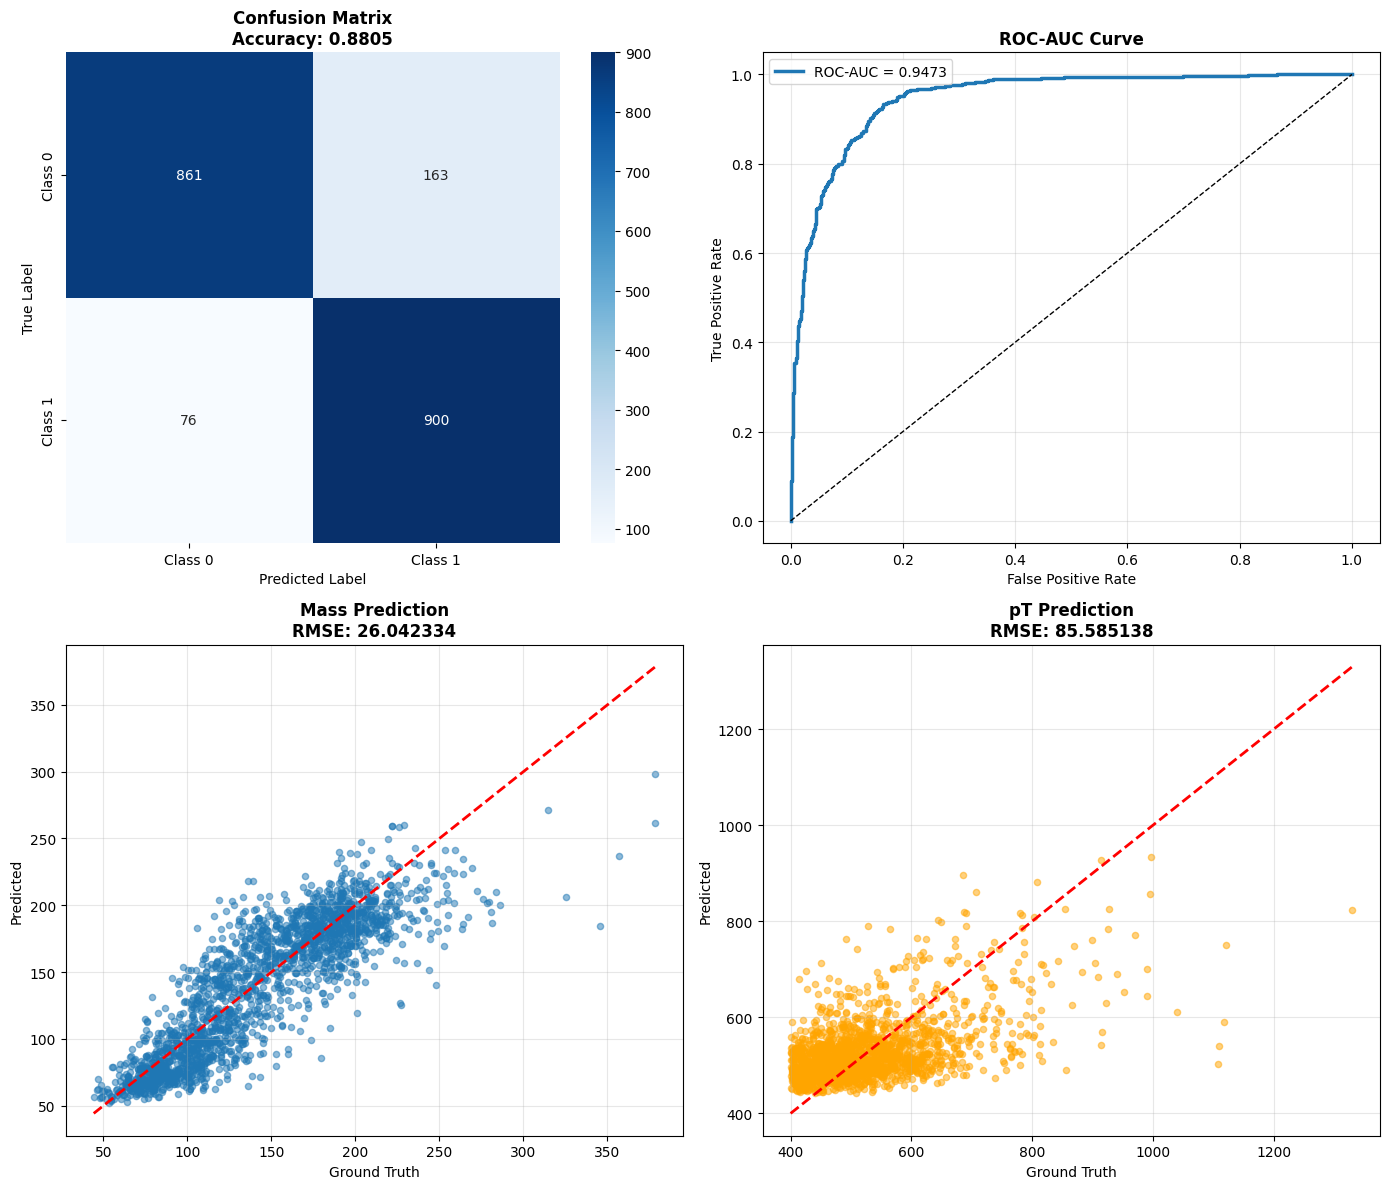

In [9]:
# Confusion Matrix
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Confusion Matrix
ax = axes[0, 0]
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
ax.set_title(f'Confusion Matrix\nAccuracy: {accuracy:.4f}', fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

# ROC-AUC Curve
ax = axes[0, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])
ax.plot(fpr, tpr, lw=2.5, label=f'ROC-AUC = {roc_auc:.4f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-AUC Curve', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Mass Prediction
ax = axes[1, 0]
ax.scatter(mass_test, mass_pred_denorm, alpha=0.5, s=20)
lims = [min(mass_test.min(), mass_pred_denorm.min()), 
        max(mass_test.max(), mass_pred_denorm.max())]
ax.plot(lims, lims, 'r--', lw=2)
ax.set_xlabel('Ground Truth')
ax.set_ylabel('Predicted')
ax.set_title(f'Mass Prediction\nRMSE: {mass_rmse:.6f}', fontweight='bold')
ax.grid(alpha=0.3)

# pT Prediction
ax = axes[1, 1]
ax.scatter(pt_test, pt_pred_denorm, alpha=0.5, s=20, color='orange')
lims = [min(pt_test.min(), pt_pred_denorm.min()), 
        max(pt_test.max(), pt_pred_denorm.max())]
ax.plot(lims, lims, 'r--', lw=2)
ax.set_xlabel('Ground Truth')
ax.set_ylabel('Predicted')
ax.set_title(f'pT Prediction\nRMSE: {pt_rmse:.6f}', fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()